In [32]:

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import TensorDataset, DataLoader

import pytorch_lightning as pl

from torchmetrics.classification import BinaryAUROC

from datetime import datetime
from xaikd import bases as xaikd_bases
from tqdm import tqdm

import numpy.typing as npt

In [2]:
WITH_LAST_LAYER_BIAS = False
DEVICE = "cpu"

In [3]:
# Build Dataset
def build_task_targets():
    bin_rep1 = np.arange(8) % 2
    bin_rep2 = (np.arange(8) //2) % 2
    bin_rep3 = (np.arange(8) // 4) % 2
    
    y_t1 = np.logical_xor(bin_rep1, bin_rep2).astype(int)
    y_t2 = np.logical_xor(bin_rep1, bin_rep3).astype(int)
    y_t3 = np.logical_xor(bin_rep2, bin_rep3).astype(int)
    
    y = np.stack([y_t1, y_t2, y_t3]).T
    
    df = pd.DataFrame(
        dict(
            x1 = bin_rep1,
            x2 = bin_rep2,
            x3 = bin_rep3,
            x1_xor_x2 = y_t1,
            x1_xor_x3 = y_t2,
            x2_xor_x3 = y_t3
        )
    )
    return df, y

df, arr_task_targets = build_task_targets()
df

,x1,x2,x3,x1_xor_x2,x1_xor_x3,x2_xor_x3
0,0,0,0,0,0,0
1,1,0,0,1,1,0
2,0,1,0,1,0,1
3,1,1,0,0,1,1
4,0,0,1,0,1,1
5,1,0,1,1,0,1
6,0,1,1,1,1,0
7,1,1,1,0,0,0


In [4]:
def generate_dataset(num_per_groups=200, seed=1):
    rng = np.random.default_rng(seed=1)
    
    df, arr_task_targets = build_task_targets()
    
    arr_xs = []
    arr_ys = []
    
    arr_centers = 2*df[["x1", "x2", "x3"]].values - 1
    
    assert arr_centers.shape[0] == 8
    
    for cix in range(8):
        center = arr_centers[cix]
        group_x =  rng.normal(scale=0.5, size=(num_per_groups, 3)) + center
        arr_xs.append(group_x)
        
        
        code = np.array(list(np.binary_repr(2, width=3))).astype(int)
    
        ys = np.tile(arr_task_targets[cix], num_per_groups).reshape((num_per_groups, 3))
        arr_ys.append(ys)
        
    X = np.vstack(arr_xs)
    y = np.vstack(arr_ys)
    
    assert X.shape[0] == y.shape[0] == num_per_groups * 8 
    
    num_datapoints = num_per_groups * 8 
    
    return train_test_split(X, y, test_size=0.5, random_state=seed)

X_train, X_test, y_train, y_test = generate_dataset() 

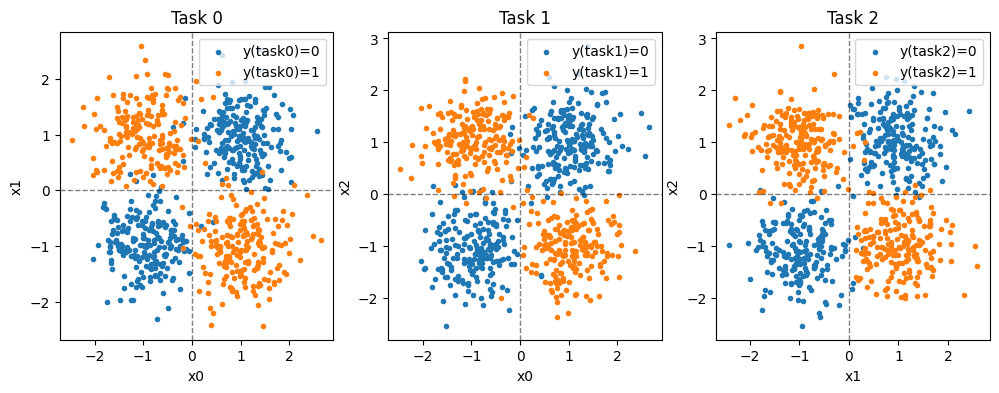

In [5]:
def viz(X, y):
    
    plt.figure(figsize=(3*4, 4))
    
    arr_coords = [
        (0, 1),
        (0, 2),
        (1, 2)
    ]
    
    for tidx in range(3):
        plt.subplot(1, 3, tidx + 1)
        plt.title(f"Task {tidx}")
        
        coord1, coord2 = arr_coords[tidx]
        for ans in [0, 1]:

            selected = y[:, tidx] == ans

            plt.scatter(
                X[selected, coord1], X[selected, coord2],
                marker=".",
                label=f"y(task{tidx})={ans}"
            )
        plt.axhline(0, ls="--", lw=1, color="k", alpha=0.5)
        plt.axvline(0, ls="--", lw=1, color="k", alpha=0.5)
        plt.legend()
        plt.xlabel(f"x{coord1}")
        plt.ylabel(f"x{coord2}")
        
viz(X_train, y_train)

# Construct Model and Train

In [98]:
class MLP(nn.Module):
    def __init__(self, num_tasks=3):
        super().__init__()
        
        d = 128
        
        self.lin1 = nn.Linear(3, d)
        self.act1 = nn.ReLU()
        self.lin2_task0 = nn.Linear(d, 2, bias=WITH_LAST_LAYER_BIAS)
        self.lin2_task1 = nn.Linear(d, 2, bias=WITH_LAST_LAYER_BIAS)
        self.lin2_task2 = nn.Linear(d, 2, bias=WITH_LAST_LAYER_BIAS)

    def forward(self, x):
        x = self.act1(self.lin1(x))
        x_task_0 = self.lin2_task0(x)
        x_task_1 = self.lin2_task1(x)
        x_task_2 = self.lin2_task2(x)
        
        return x_task_0, x_task_1, x_task_2
        
        return out
    def __str__(self):
        d, _ = self.lin1.weight.shape
        return f"MLP(d={d}, last_layer_bias={WITH_LAST_LAYER_BIAS})"
def ano():
    
    out = MLP()(torch.randn(10, 3))
    
    print(f"santity check: {MLP()} callable")
ano()

santity check: MLP(d=128, last_layer_bias=False) callable


In [99]:
class ModelWrapper(pl.LightningModule):
    def __init__(self, encoder, lr=1e-3, weight_decay=0.0):
        super().__init__()

        self.encoder = encoder
        
        self.weight_decay = weight_decay
        self.lr = lr

    def forward(self, x):
        embedding = self.encoder(x)
        return embedding

    def configure_optimizers(self):

        optimizer = torch.optim.SGD(
            self.parameters(), lr=self.lr, momentum=0.0, weight_decay=self.weight_decay
        )

        return optimizer

    def compute_metric(self, batch, prefix):

        x, y = batch

        arr_logits = self.encoder(x)

        loss = 0
        for tidx in range(3):
            y_task = y[:, tidx].long()
            logits_task = arr_logits[tidx]
            loss += (1/3)*F.cross_entropy(
                logits_task, 
                y_task
            )

        return loss

    def training_step(self, train_batch, batch_idx):

        loss = self.compute_metric(train_batch, "train")

        self.log("train_loss", loss, on_epoch=True, prog_bar=True)
        return loss

    def summary_metric(self, prefix):
        raise
        metric = self.metrics[prefix]
        value = metric.compute()

        self.log(f"{prefix}_acc", value)

        metric.reset()


In [100]:
pl.seed_everything(1)

dl_train = DataLoader(
    TensorDataset(
        torch.from_numpy(X_train).float(),
        torch.from_numpy(y_train).float()
    ),
    batch_size=64,
    shuffle=True,
)

dl_train_noshuffle = DataLoader(
    TensorDataset(
        torch.from_numpy(X_train).float(),
        torch.from_numpy(y_train).float()
    ),
    batch_size=64,
    shuffle=False,
)

dl_test = DataLoader(
    TensorDataset(
        torch.from_numpy(X_test).float(),
        torch.from_numpy(y_test).float()
    ),
    batch_size=64,
    shuffle=True,
)

model  = MLP()

trainer = pl.Trainer(
    max_epochs=500,
    default_root_dir="/tmp",
)

trainer.fit(ModelWrapper(model), dl_train, dl_test)

Global seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/pat/projects/xai-kd/.venv/lib/python3.11/site-packages/pytorch_lightning/trainer/configuration_validator.py:69: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")

  | Name    | Type | Params
---------------------------------
0 | encoder | MLP  | 1.3 K 
---------------------------------
1.3 K     Trainable params
0         Non-trainable params
1.3 K     Total params
0.005     Total estimated model params size (MB)
/home/pat/projects/xai-kd/.venv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:438: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value 

Epoch 499: 100%|███████████████████████████████████████| 13/13 [00:00<00:00, 326.59it/s, v_num=3, train_loss_step=0.383, train_loss_epoch=0.380]

`Trainer.fit` stopped: `max_epochs=500` reached.


Epoch 499: 100%|███████████████████████████████████████| 13/13 [00:00<00:00, 307.59it/s, v_num=3, train_loss_step=0.383, train_loss_epoch=0.380]


In [101]:
def estimate_task_auroc(model, dl, task_id):
    metric_auroc = BinaryAUROC()

    for x, y in dl:
        task_logit = model(x)[task_id]
        
        assert task_logit.shape == (x.shape[0], 2)
        
        p_y0_gv_x = F.softmax(task_logit, dim=1)[:, 0]
        
        task_target = y[:, task_id]
        metric_auroc.update(p_y0_gv_x, task_target)

    auroc = float(metric_auroc.compute())
    auroc = 1-auroc if auroc < 0.5 else auroc
    return auroc

def compute_aurocs():
    
    stats = dict()
    
    for tidx in range(3):
        
        for label, dl in [
            ("train", dl_train),
            ("test", dl_test)
        ]:            
            stats[f"auroc_task_{tidx}_{label}"] = estimate_task_auroc(model, dl, tidx)
    
    return stats

ref_stats = compute_aurocs()
ref_stats

{'auroc_task_0_train': 0.9908680953085423,
 'auroc_task_0_test': 0.9867337187752128,
 'auroc_task_1_train': 0.9911694843322039,
 'auroc_task_1_test': 0.9825265742838383,
 'auroc_task_2_train': 0.9927995936013758,
 'auroc_task_2_test': 0.9867086224257946}

# Extract Grad

In [102]:

def grad_hook(mod, inp, outp):
    outp.retain_grad()
    setattr(mod, "__outp", outp)


def get_winning_logits(logits, targets):

    wining_targets = torch.argmax(logits, dim=1)
    return (F.one_hot(wining_targets, num_classes=2) * logits).sum(dim=1)


def get_target_logits(logits, targets):

    return (F.one_hot(targets, num_classes=2) * logits).sum(dim=1)



def get_difference_between_logits(logits,  targets):

    wining_targets = torch.argmax(logits, dim=1)
    
    onehot = F.one_hot(wining_targets, num_classes=2)
    winning_logits =  onehot * logits
    not_winning_logits = (1-onehot) * logits
    
    
    return (winning_logits - not_winning_logits).sum(dim=1)

    
def extract_act_grad(model, dl, task_id, output_func=get_difference_between_logits):
    module_name = "act1"

    arr_logodd = []
    arr_act = []
    arr_ctx = []
    module = getattr(model, module_name)
    for x, y in dl:
                
        try:

            x.requires_grad_()
            hook = module.register_forward_hook(grad_hook)

            arr_logits = model(x)
        
            task_logit = arr_logits[task_id]
            y_task = y[:, task_id].long()

            output_quantity = output_func(task_logit, y_task)
            (output_quantity).sum().backward()
            
            act = getattr(module, "__outp")

            
            ctx = act.grad.detach().numpy()
            act = act.detach().numpy()
            arr_act.append(act)
            arr_ctx.append(ctx)
            
            
        finally:
            hook.remove()

    arr_act = np.vstack(arr_act)
    arr_ctx = np.vstack(arr_ctx)

    return None, arr_act, arr_ctx

extract_act_grad(model, dl_train_noshuffle, 0)

(None,
 array([[0.0094004 , 0.3819442 , 0.        , ..., 0.        , 0.        ,
         0.03168772],
        [0.        , 0.        , 0.6038167 , ..., 0.        , 0.        ,
         0.87731737],
        [0.3210694 , 1.7922385 , 0.        , ..., 0.85732865, 0.        ,
         0.        ],
        ...,
        [0.        , 1.4389441 , 0.05538435, ..., 0.90013903, 0.        ,
         0.        ],
        [0.53538716, 0.87440324, 0.        , ..., 0.        , 0.04493117,
         0.        ],
        [0.        , 1.4518572 , 0.        , ..., 0.7988235 , 0.        ,
         0.        ]], dtype=float32),
 array([[-0.14503968, -0.0567425 , -0.07650674, ..., -0.08151135,
         -0.0198498 , -0.23972607],
        [-0.14503968, -0.0567425 , -0.07650674, ..., -0.08151135,
         -0.0198498 , -0.23972607],
        [ 0.14503968,  0.0567425 ,  0.07650674, ...,  0.08151135,
          0.0198498 ,  0.23972607],
        ...,
        [ 0.14503968,  0.0567425 ,  0.07650674, ...,  0.08151135,
  

### Viz Eigenvalues

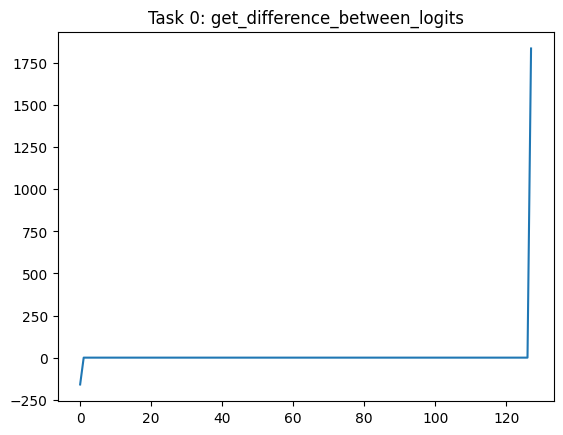

In [103]:
def ano():
    task_id = 0
    output_func = get_difference_between_logits
    arr_logodds, arr_act, arr_ctx = extract_act_grad(
        model, dl_train_noshuffle, task_id,
        output_func=output_func
    )

    prca_cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
    
    eigvals = np.linalg.eigvalsh(prca_cov)
    plt.plot(eigvals)
    plt.title(f"Task {task_id}: {output_func.__name__}")
ano()
    

In [123]:
def ano():
    task_id = 0
    
    W = model.lin2_task0.weight.detach().cpu().numpy()
    w = W / np.linalg.norm(W, axis=1, keepdims=True)
    cosine = np.dot(w[0, :], w[1, :])
    print(f"cosine={cosine:.4f}")
    
    delta_w = W[0, :] - W[1, :]
    delta_w = delta_w / np.linalg.norm(delta_w)
    
    
    
    arr_logodds, arr_act, arr_ctx = extract_act_grad(
        model, dl_train_noshuffle, task_id,
        output_func=get_difference_between_logits
    )

    
    for basis_class in [
        GradPCA,
        PRCASortAbs,
        PRCARecon
    ]:
        
        u = basis_class(arr_logodds, arr_act, arr_ctx).get_Uk(k=1)[:, 0]

        print(f"> [{basis_class.__name__:>15s}] cosine(delta_w)={np.dot(delta_w, u):.4f}")
    
ano()

cosine=-0.3935
> [        GradPCA] cosine(delta_w)=-1.0000
> [    PRCASortAbs] cosine(delta_w)=0.9592
> [      PRCARecon] cosine(delta_w)=0.9418


# Constructing Basis

In [92]:
def _solve_eigvecs(cov, sort_func=lambda x: x):
    eigvals, eigvecs = np.linalg.eigh(cov)

    assert len(eigvals.shape) == 1

    indices = np.argsort(-sort_func(eigvals))
    eigvals = eigvals[indices]
    eigvecs = eigvecs[:, indices]

    return eigvals, eigvecs

## Baselines: PCA, GradPCA

In [93]:
class BasisInterface:
    def get_Uk(self, k: int) -> npt.NDArray:
        raise NotImplementedError()   

class PCA(BasisInterface):
    def __init__(self, arr_logodds, arr_act, arr_ctx, layer=None, task_id=None):
        cov = arr_act.T @ arr_act
        self.eigvals, self.U = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

class GradPCA(BasisInterface):
    def __init__(self, arr_logodds, arr_act, arr_ctx, layer=None, task_id=None):
        cov = arr_ctx.T @ arr_ctx
        self.eigvals, self.U = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]
    
    
    
class Task0DiffWeight(BasisInterface):
    def __init__(self, arr_logodds, arr_act, arr_ctx, layer=None, task_id=None):

        W = model.lin2_task0.weight.detach().numpy()
        
        u = W[0, :] - W[1, :]
        u = u / np.linalg.norm(u)
        self.U = np.outer(u, u)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]
    
    
class Task0Weight0(BasisInterface):
    def __init__(self, arr_logodds, arr_act, arr_ctx, layer=None, task_id=None):

        W = model.lin2_task0.weight.detach().numpy()
        
        u = W[0, :]
        u = u / np.linalg.norm(u)
        self.U = np.outer(u, u)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]
    
    
class Task0Weight1(BasisInterface):
    def __init__(self, arr_logodds, arr_act, arr_ctx, layer=None, task_id=None):

        W = model.lin2_task0.weight.detach().numpy()
        
        u = W[1, :]
        u = u / np.linalg.norm(u)
        self.U = np.outer(u, u)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

## PRCA Variants

In [94]:
class PRCA(BasisInterface):
    def __init__(self, arr_logodds, arr_act, arr_ctx, layer=None, task_id=None):
        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        self.eigvals, self.U = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]


class PRCAAfterGradPCA(BasisInterface):
    def __init__(self, arr_logodds, arr_act, arr_ctx, layer=None, task_id=None):
        self.arr_act = arr_act
        self.arr_ctx = arr_ctx
        _, self.U_gradpca = _solve_eigvecs(arr_ctx.T @ arr_ctx)
        
    def get_Uk(self, k: int):
        U_k_gradpca = self.U_gradpca[:, :k]
        P = U_k_gradpca @ U_k_gradpca.T
        A = self.arr_act @ P
        C = self.arr_ctx @ P
        
        ccov = A.T @ C + C.T @ A

        _, U_k = _solve_eigvecs(ccov)
        return U_k



class PRCASortAbs(BasisInterface):
    def __init__(self, arr_logodds, arr_act, arr_ctx, layer=None, task_id=None):
        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        self.eigvals, self.U = _solve_eigvecs(cov, sort_func=np.abs)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

class PRCAScaledWithLogOdd(BasisInterface):
    def __init__(self, arr_logodds, arr_act, arr_ctx, layer=None, task_id=None):

        assert len(arr_act.shape) == 2 \
            and len(arr_logodds.shape) == 1 \
            and arr_logodds.shape == (arr_act.shape[0],)

        arr_act = arr_logodds.reshape((-1, 1)) * arr_act 
               
        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        self.eigvals, self.U = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

class PRCAScaledWithSignLogOdd(BasisInterface):
    def __init__(self, arr_logodds, arr_act, arr_ctx, layer=None, task_id=None):

        assert len(arr_act.shape) == 2 \
            and len(arr_logodds.shape) == 1 \
            and arr_logodds.shape == (arr_act.shape[0],)

        arr_act = np.sign(arr_logodds).reshape((-1, 1)) * arr_act 
               
        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        self.eigvals, self.U = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]


class PRCAScaledWithSignLogOddSubtractMean(BasisInterface):
    def __init__(self, arr_logodds, arr_act, arr_ctx, layer=None, task_id=None):

        assert len(arr_act.shape) == 2 \
            and len(arr_logodds.shape) == 1 \
            and arr_logodds.shape == (arr_act.shape[0],)

        factors = np.sign(arr_logodds)
        factors = 2*factors - np.mean(factors)
        arr_act = factors.reshape((-1, 1)) * arr_act 
               
        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        sself.eigvals, elf.U = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]


class PRCAScaledWithLogOddFromSurrogate(BasisInterface):
    def __init__(self, arr_logodds, arr_act, arr_ctx, layer=None, task_id=None):

        assert len(arr_act.shape) == 2 \
            and len(arr_logodds.shape) == 1 \
            and arr_logodds.shape == (arr_act.shape[0],)

        factors = (arr_act * arr_ctx).sum(axis=1, keepdims=True)
        arr_act = factors * arr_act 
               
        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        self.eigvals, self.U = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]


class PRCAScaledWithLogOddSubtractedMean(BasisInterface):
    def __init__(self, arr_logodds, arr_act, arr_ctx, layer=None, task_id=None):

        assert len(arr_act.shape) == 2 \
            and len(arr_logodds.shape) == 1 \
            and arr_logodds.shape == (arr_act.shape[0],)

        factors = (2*arr_logodds - 0.1 * np.mean(arr_logodds))
        
        arr_act = factors.reshape((-1, 1)) * arr_act 
               
        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        self.eigvals, self.U = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

### PRCA-Recon

In [95]:
class PRCAReconNonGreedyLearner:
    def __init__(self, task_id, layer):
        self.task_id = task_id
        self.layer = layer
    def fit(
        self, arr_logodds: npt.NDArray, arr_act: npt.NDArray, arr_ctx: npt.NDArray, k: int,  U_init=None, device="cpu",
    ) -> npt.NDArray:
        n, d = arr_act.shape

        assert arr_ctx.shape == arr_act.shape, arr_ctx.shape
        
        lr = 1e-3
        epochs = 100
                
        n, d,  = arr_act.shape

        arr_act = arr_act / ((np.mean(arr_act**2) ** (1 / 2)) * (d ** (1 / 4)))
        arr_ctx = arr_ctx / ((np.mean(arr_ctx**2) ** (1 / 2)) * (d ** (1 / 4)))
        
        arr_act: torch.Tensor = torch.from_numpy(arr_act).to(device)
        arr_ctx: torch.Tensor = torch.from_numpy(arr_ctx).to(device)


        linear_layer = torch.nn.Linear(k, d, bias=False)
        trng = torch.Generator()
        trng.manual_seed(1)
        if U_init is None:
            
            U_init = torch.randn((k, d), generator=trng)
        else:
            U_init = torch.from_numpy(U_init.T)
            
        linear_layer.weight = torch.nn.Parameter(U_init)
    
        ortho_layer = torch.nn.utils.parametrizations.orthogonal(linear_layer).to(device)
        assert ortho_layer.weight.shape == (k, d)
        
        optimizer = torch.optim.Adam(ortho_layer.parameters(), lr=lr)

        rel = (arr_act * arr_ctx).sum(dim=1)

        pgb = tqdm(range(epochs), desc=f"{self.__class__.__name__} (k={k})", disable=True)
        for epoch in pgb:
            optimizer.zero_grad()
            
            # shape: (k, d)
            U = ortho_layer.weight

            act_proj = arr_act @ U.T

            ctx_proj = arr_ctx @ U.T
            assert act_proj.shape == (n, k), act_proj.shape
            rel_recon = (act_proj * ctx_proj).sum(dim=1)

            loss = ((rel - rel_recon).abs()).mean()
            
            loss.backward()
        
            optimizer.step()

            loss = loss.detach().cpu().numpy()
                
            pgb.set_description_str(f"{self.__class__.__name__} (k={k}) loss={loss:.4e}")
            
        U =  ortho_layer.weight.T.detach().cpu().numpy()
        
        # sanity_check
        np.testing.assert_allclose(U.T @ U, np.eye(k), atol=1e-4)

        return U


class PRCARecon(BasisInterface):
    def __init__(self, arr_logodds, arr_act, arr_ctx, layer=None, task_id=None):
        self.arr_act = arr_act
        self.arr_ctx = arr_ctx
        self.arr_logodds = arr_logodds
        
        self.layer = layer
        self.task_id = task_id
        self.is_slow = True
        
    def get_Uk(self, k: int):

        return PRCAReconNonGreedyLearner(
            layer=self.layer,
            task_id=self.task_id
        ).fit(
            self.arr_logodds,
            self.arr_act, self.arr_ctx, 
            k=k,
            U_init=PRCASortAbs(
                arr_logodds=self.arr_logodds,
                arr_act=self.arr_act,
                arr_ctx=self.arr_ctx
            ).get_Uk(k),
            device=DEVICE
        )

## PRCA-LH (todo)

In [96]:
# class SecondModuleForTask(nn.Module):
#     def __init__(self, module, task_id):
#         super().__init__()
#         self.task_id = task_id
#         self.module = module

#     def forward(self, x):
#         return self.module(x)[:, self.task_id]
        

# def split_model_for_task(model, task_id):

#     first_module = nn.Sequential(
#         model.lin1,
#         model.act1
#     )


#     second_module = SecondModuleForTask(model.lin2, task_id)

#     return first_module, second_module
    

# @torch.no_grad()
# def ano():

#     x = torch.from_numpy(X_train).float()
    
#     for task_id in range(3):
#         m1, m2 = split_model_for_task(model, task_id)
#         np.testing.assert_allclose(
#             m2(m1(x)),
#             model(x)[task_id]
#         )
#         print(f"sanity check: Task {task_id} passed!")
# ano()

# Comparison

In [97]:
def construct_fh(Uk):
    def fh(mod, inp, outp):
        return outp @ (Uk@Uk.T)
    return fh

def compute_task_auroc_at_k(
    model, task_id, arr_ks,
    arr_basis_names,
):
    arr_logodds, arr_act, arr_ctx = extract_act_grad(model, dl_train_noshuffle, task_id)
    arr_stat_rows = []
    
    module = getattr(model, "act1")
    
    for basis_class in arr_basis_names:
        basis: BasisInterface = basis_class(
            arr_logodds=arr_logodds,
            arr_act=arr_act,
            arr_ctx=arr_ctx
        )
        
        for k in arr_ks:
            Uk = torch.from_numpy(basis.get_Uk(k))
            row = dict(
                last_layer_bias=WITH_LAST_LAYER_BIAS,
                task_id=task_id, 
                k=k,   
                basis_name=basis_class.__name__,
            )
            try:
                hook = module.register_forward_hook(construct_fh(Uk))
                
                for label, dl in [
                    ("train", dl_train_noshuffle),
                    ("test", dl_test)
                ]:
                    row[f"auroc_{label}"] = estimate_task_auroc(model, dl, task_id)
                
            finally:
                hook.remove()
            arr_stat_rows.append(row)
            
    df = pd.DataFrame(arr_stat_rows).sort_values(by=["k", f"auroc_test"], ascending=[True, False])
    
    return df

compute_task_auroc_at_k(
    model, 
    task_id=0, 
    arr_ks=np.arange(1, 3).tolist()  + [128],
    arr_basis_names=[
        PCA,
        GradPCA,
        Task0DiffWeight,
            Task0Weight0,
            Task0Weight1,
        PRCA,  
        PRCASortAbs,
        PRCARecon,
    ]
)

,last_layer_bias,task_id,k,basis_name,auroc_train,auroc_test
21,False,0,1,PRCARecon,0.989842,0.985195
3,False,0,1,GradPCA,0.989611,0.984845
6,False,0,1,Task0DiffWeight,0.989611,0.984842
15,False,0,1,PRCA,0.960145,0.969102
18,False,0,1,PRCASortAbs,0.960145,0.969102
12,False,0,1,Task0Weight1,0.966331,0.963316
9,False,0,1,Task0Weight0,0.904278,0.908656
0,False,0,1,PCA,0.533891,0.516047
4,False,0,2,GradPCA,0.989611,0.984845
7,False,0,2,Task0DiffWeight,0.989611,0.984845


In [18]:
raise

RuntimeError: No active exception to reraise

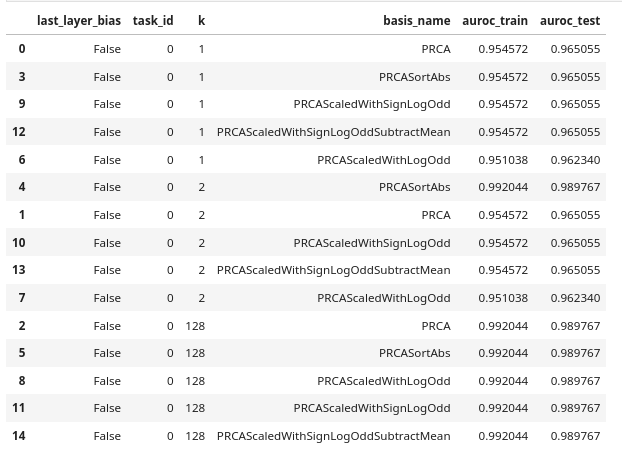

# Accuracy Curves

In [ ]:
def viz(arr_basis_names=["pca", "gpca", "prca-sortabs"], max_k=10):
    
    arr_task_ids = np.arange(3)
    plt.figure(figsize=(5*3, 3))
    
    d = model.lin1.weight.shape[0]

    arr_ks = np.linspace(0, max_k).astype(int).tolist() + [d]
    
    plt.suptitle(model, y=1.05)
    
    for task_id in tqdm(arr_task_ids):
        plt.subplot(1, 3, task_id+1)
        plt.title(f"Task {task_id}")
        df = compute_task_auroc_at_k(model, task_id=task_id, arr_ks=arr_ks, arr_basis_names=arr_basis_names)
        
        for bix, basis_name in enumerate(arr_basis_names):
            _df = df[
                (df.basis_name == basis_name) 
            ]
            
            if bix == 0:
                
                ref = ref_stats[f"auroc_task_{task_id}_test"]
                plt.title(f"Task {task_id} (auroc={ref:.4f})")

                plt.axhline(
                    ref,
                    ls=":",
                    lw=1,
                    color="k",
                    label="orig-model:test"
                )
            selected = _df.k < max_k
            for label in ["test"]:
                plt.plot(
                    _df.k[selected],
                    _df[f"auroc_{label}"][selected],
                    color="black" if basis_name == "pca" else None,
                    ls="-",
                    marker=".",
                    label=f"{basis_name}:{label}"
                )
        plt.ylim([0.5-0.01, 1.01])
        if task_id == 0:
            plt.legend()
            plt.ylabel("AUROC")
        plt.xlabel(f"Subspace Dimensions $K$\n(d={d})")
viz(
    arr_basis_names=[
       "pca", 
        "prca-sortabs", 
        "prca-sign-align-sortabs", 
        "prca-pos-pair-sortabs", 
        "prca-recon",
        "pca-lh-k1",
    ]
)

# Decision Boundary

In [ ]:
def decision_boundary(task_id, arr_ks=[1, 2, 3, 4]):

    arr_basis_names = [
        "pca", 
        "prca-sortabs", 
        "prca-sign-align-sortabs", 
        "prca-pos-pair-sortabs", 
        "prca-recon",
        "pca-lh-k1"
    ]
        
    d = model.lin1.weight.shape[0]
    arr_ks = arr_ks + [d]
    
    nrows = len(arr_basis_names)
    ncols = len(arr_ks)
    
    arr_coords = [
        (0, 1),
        (0, 2),
        (1, 2)
    ]
    
    _xx = np.linspace(-3, 3, 20)
    module = getattr(model, "act1")
    plt.figure(figsize=(2*ncols, 2*nrows))
    
    auroc_train = ref_stats[f"auroc_task_{task_id}_train"]
    auroc_test = ref_stats[f"auroc_task_{task_id}_test"]
    plt.suptitle(
        f"Task {task_id} (auroc(train,test)={auroc_train:.4f},{auroc_test:.4f})",
        y=0.95
    )
    
    arr_act, arr_ctx = extract_act_grad(model, dl_train_noshuffle, task_id)
    
    for bix, basis_name in enumerate(arr_basis_names):
        
        U = estimate_basis(basis_name, arr_act, arr_ctx)

        coord_1, coord_2 = arr_coords[task_id]

        X = np.zeros((400, 3))
        
        xx, yy = np.meshgrid(_xx, _xx)
        
        X[:, coord_1] = xx.reshape(-1)
        X[:, coord_2] = yy.reshape(-1)
        
        X = torch.from_numpy(X).float()
        for kix, k in enumerate(arr_ks):
            Uk = torch.from_numpy(U[:, :k])
            plt.subplot(nrows, ncols, bix * ncols + kix + 1)
            if bix == 0:
                plt.title(f"k={k}/{d}")
            
            try:
                hook = module.register_forward_hook(construct_fh(Uk))
                
                task_logits = model(X)[task_id].detach().numpy()
                
                auroc = estimate_task_auroc(
                    model,
                    dl_test,
                    task_id=task_id
                )
            
            finally:
                hook.remove()
                     
            plt.contourf(
                X[:, coord_1].reshape((20, 20)),
                X[:, coord_2].reshape((20, 20)),
                task_logits.reshape((20, 20)),
                levels=20,
            )
            
            plt.text(
                -2.5, -2.5, 
                f"auroc(test)={auroc:.4f}", 
                fontsize="small",
            )
            
            plt.axhline(0, ls="--", lw=1, color="k")
            plt.axvline(0, ls="--", lw=1, color="k")
            
            if bix == nrows - 1:
                plt.xlabel(f"x{coord_1}")
                plt.xticks([-3, 0, 3])

            else:
                plt.xticks([])
            if kix == 0:
                plt.ylabel(f"{basis_name}\nx{coord_2}")
                plt.yticks([-3, 0, 3])
            else:
                plt.yticks([])
decision_boundary(task_id=0)

In [ ]:
for task_id in range(3):
    decision_boundary(task_id=task_id)
    plt.show()

In [ ]:
print(f"Finished at {datetime.now()}")